In [ ]:
from google.colab import drive

# Google Drive mount karo
drive.mount('/content/drive')

print(" Drive mounted successfully!")

Mounted at /content/drive
 Drive mounted successfully!


In [ ]:
!pip install git+https://github.com/openai/CLIP.git


  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-huihuglq
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-huihuglq
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=d82fc466036b2ae25f2c8cc20b796de75eb2c7b364780998159632d91ad15241
  Stored in directory: /tmp/pip-ephem-wheel-cache-mwlhxjg9/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
!pip install git+https://github.com/openai/CLIP.git --quiet


  Preparing metadata (setup.py) ... done


In [ ]:
!pip install fpdf


In [ ]:
import os
import shutil
import random
from tqdm import tqdm
from google.colab import drive

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 2: Define Paths
original_dataset_path = "/content/drive/MyDrive/Pneumonia_ReBalanced_Dataset"
output_base_path = "/content/drive/MyDrive/Pneumonia_80_12_8_Splitted"  # new splitted dataset

# Fresh folder (purana delete kar ke)
if os.path.exists(output_base_path):
    shutil.rmtree(output_base_path)
os.makedirs(output_base_path, exist_ok=True)

train_path = os.path.join(output_base_path, "train")
val_path   = os.path.join(output_base_path, "val")
test_path  = os.path.join(output_base_path, "test")

os.makedirs(train_path, exist_ok=True)
os.makedirs(val_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

# Categories (dataset ke andar ke folder names)
categories = ["Normal", "Bacterial Pneumonia", "Viral Pneumonia"]

# Ratios
train_ratio = 0.80
val_ratio   = 0.08
test_ratio  = 0.12

def split_images():
    for category in categories:
        category_path = os.path.join(original_dataset_path, category)

        if not os.path.exists(category_path):
            print(f" Folder not found: {category_path}")
            continue

        images = os.listdir(category_path)
        random.shuffle(images)

        total_count = len(images)
        train_count = int(total_count * train_ratio)
        val_count   = int(total_count * val_ratio)
        test_count  = total_count - train_count - val_count  # jo bacha

        train_images = images[:train_count]
        val_images   = images[train_count:train_count + val_count]
        test_images  = images[train_count + val_count:]

        # Category folders
        train_category_path = os.path.join(train_path, category)
        val_category_path   = os.path.join(val_path, category)
        test_category_path  = os.path.join(test_path, category)

        os.makedirs(train_category_path, exist_ok=True)
        os.makedirs(val_category_path, exist_ok=True)
        os.makedirs(test_category_path, exist_ok=True)

        # Copy Train Images
        for img_name in tqdm(train_images, desc=f"Copying Train - {category}"):
            shutil.copy2(os.path.join(category_path, img_name),
                         os.path.join(train_category_path, img_name))

        # Copy Val Images
        for img_name in tqdm(val_images, desc=f"Copying Val - {category}"):
            shutil.copy2(os.path.join(category_path, img_name),
                         os.path.join(val_category_path, img_name))

        # Copy Test Images
        for img_name in tqdm(test_images, desc=f"Copying Test - {category}"):
            shutil.copy2(os.path.join(category_path, img_name),
                         os.path.join(test_category_path, img_name))

        print(f" {category}: Train={train_count}, Val={val_count}, Test={test_count}")

# Run the Splitting Process
split_images()

print("\n Dataset splitting complete!")
print(f" New dataset saved here: {output_base_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Copying Test - Normal: 100%|██████████| 600/600 [00:08<00:00, 72.55it/s]


 Normal: Train=4000, Val=400, Test=600


Copying Test - Bacterial Pneumonia: 100%|██████████| 600/600 [00:08<00:00, 69.14it/s]


 Bacterial Pneumonia: Train=4000, Val=400, Test=600


Copying Test - Viral Pneumonia: 100%|██████████| 600/600 [00:09<00:00, 66.10it/s]

 Viral Pneumonia: Train=4000, Val=400, Test=600

 Dataset splitting complete!
 New dataset saved here: /content/drive/MyDrive/Pneumonia_80_12_8_Splitted


In [ ]:
import os

# Check agar folder Drive me exist karta hai
print("Exists? ->", os.path.exists("/content/drive/MyDrive/Pneumonia_80_12_8_Splitted"))

# Uske andar ka structure dikhado
for root, dirs, files in os.walk("/content/drive/MyDrive/Pneumonia_80_12_8_Splitted"):
    print("", root, "->", len(files), "files")
    for d in dirs:
        print("   -", d)


Exists? -> True
 /content/drive/MyDrive/Pneumonia_80_12_8_Splitted -> 0 files
   - train
   - val
   - test
 /content/drive/MyDrive/Pneumonia_80_12_8_Splitted/train -> 0 files
   - Normal
   - Bacterial Pneumonia
   - Viral Pneumonia
 /content/drive/MyDrive/Pneumonia_80_12_8_Splitted/train/Normal -> 4000 files
 /content/drive/MyDrive/Pneumonia_80_12_8_Splitted/train/Bacterial Pneumonia -> 4000 files
 /content/drive/MyDrive/Pneumonia_80_12_8_Splitted/train/Viral Pneumonia -> 4000 files
 /content/drive/MyDrive/Pneumonia_80_12_8_Splitted/val -> 0 files
   - Normal
   - Bacterial Pneumonia
   - Viral Pneumonia
 /content/drive/MyDrive/Pneumonia_80_12_8_Splitted/val/Normal -> 400 files
 /content/drive/MyDrive/Pneumonia_80_12_8_Splitted/val/Bacterial Pneumonia -> 400 files
 /content/drive/MyDrive/Pneumonia_80_12_8_Splitted/val/Viral Pneumonia -> 400 files
 /content/drive/MyDrive/Pneumonia_80_12_8_Splitted/test -> 0 files
   - Normal
   - Bacterial Pneumonia
   - Viral Pneumonia
 /content/driv

In [ ]:
!cp -r "/content/drive/MyDrive/Pneumonia_80_12_8_Splitted" "/content/"


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

# =========================
# Step 1: Paths
# =========================
BASE_DIR = "/content/drive/MyDrive/pneumonia_detection_system"
MODEL_DIR = os.path.join(BASE_DIR, "model")
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "latest_mobilenetv2_pneumonia_balanced.keras")

# Local dataset path (copied from Drive to /content/)
DATASET_BASE = "/content/Pneumonia_80_12_8_Splitted"
TRAIN_DIR = os.path.join(DATASET_BASE, "train")
VAL_DIR   = os.path.join(DATASET_BASE, "val")
TEST_DIR  = os.path.join(DATASET_BASE, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# =========================
# Step 2: Data Generators
# =========================
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    shear_range=0.25
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# =========================
# Step 3: Compute Class Weights
# =========================
classes = train_generator.classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes),
    y=classes
)
class_weights = dict(enumerate(class_weights))
print("Computed Class Weights:", class_weights)

# =========================
# Step 4: Custom Focal Loss
# =========================
def focal_loss(gamma=2., alpha=1.):
    def focal_crossentropy(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        pt = tf.reduce_sum(y_true * y_pred, axis=-1)
        fl = alpha * tf.pow(1. - pt, gamma) * ce
        return fl
    return focal_crossentropy

# =========================
# Step 5: Build Model
# =========================
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # freeze initially

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)   # extra dense layer for better separation
x = Dropout(0.3)(x)
predictions = Dense(3, activation='softmax', name="output_layer")(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=focal_loss(gamma=2., alpha=1.0),
              metrics=['accuracy',
                       tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall')])

# =========================
# Step 6: Training Phase 1 (Frozen Base)
# =========================
checkpoint = ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1)

print("===== Training Phase 1 (Frozen Base) =====")
history1 = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[checkpoint, reduce_lr]   # early_stop removed
)

# =========================
# Step 7: Fine-Tuning Phase 2 (Unfreeze Top Layers)
# =========================
base_model.trainable = True
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss=focal_loss(gamma=2., alpha=1.0),
              metrics=['accuracy',
                       tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall')])

print("===== Training Phase 2 (Fine-Tuning Top Layers, 30 Epochs) =====")
history2 = model.fit(
    train_generator,
    epochs=30,   # 30 epochs
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[checkpoint, reduce_lr]   # early_stop removed
)

# =========================
# Step 8: Save Final Model
# =========================
model.save(MODEL_PATH)
print(f" Final Model saved at {MODEL_PATH}")

# =========================
# Step 9: Evaluate on Test Set
# =========================
final_model = tf.keras.models.load_model(MODEL_PATH,
                                         custom_objects={'focal_crossentropy': focal_loss()})
test_loss, test_acc, test_prec, test_rec = final_model.evaluate(test_generator)
print(f"\n Final Test Accuracy: {test_acc*100:.2f}%")
print(f"Precision: {test_prec:.3f}, Recall: {test_rec:.3f}")

# =========================
# Step 10: Print last Conv layer for Grad-CAM
# =========================
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        print(" Last Conv Layer for Grad-CAM:", layer.name)
        break


Found 12000 images belonging to 3 classes.
Found 1200 images belonging to 3 classes.
Found 1800 images belonging to 3 classes.
Computed Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
===== Training Phase 1 (Frozen Base) =====


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4366 - loss: 0.5276 - precision: 0.4998 - recall: 0.1618
Epoch 1: val_accuracy improved from -inf to 0.67333, saving model to /content/drive/MyDrive/pneumonia_detection_system/model/latest_mobilenetv2_pneumonia_balanced.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 437s 1s/step - accuracy: 0.4367 - loss: 0.5274 - precision: 0.5001 - recall: 0.1620 - val_accuracy: 0.6733 - val_loss: 0.2658 - val_precision: 0.8192 - val_recall: 0.3700 - learning_rate: 1.0000e-04
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5993 - loss: 0.3254 - precision: 0.6942 - recall: 0.3641
Epoch 2: val_accuracy improved from 0.67333 to 0.69833, saving model to /content/drive/MyDrive/pneumonia_detection_system/model/latest_mobilenetv2_pneumonia_balanced.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 421s 1s/step - accuracy: 0.5993 - loss: 0.3254 - precision: 0.6942 - recall: 0.3641 - val_accuracy: 0.6983 - val_loss: 0.2435 - val_precision: 0.7902 - val_re

In [1]:
# ============================================
# CELL 1 — GOOGLE DRIVE MOUNT
# ============================================

from google.colab import drive

drive.mount('/content/drive', force_remount=False)

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


PNEUMOSCAN AI — MobileNetV2 Evaluation

Model Path:
/content/drive/MyDrive/pneumonia_detection_system/model/latest_mobilenetv2_pneumonia_balanced.keras

Test Dataset:
/content/drive/MyDrive/Pneumonia_90_10_Splitted/test

Evaluation Image Size: (224, 224)
Batch Size: 32
Samples Per Class: 100

Classes:
  0: Bacterial Pneumonia
  1: Viral Pneumonia
  2: Normal

Model and dataset paths verified successfully.

CREATING EVALUATION TEST SET
Bacterial Pneumonia: sampled 100 of 500 images.
Viral Pneumonia: sampled 100 of 500 images.
Normal: sampled 100 of 500 images.
Total sampled images: 300

LOADING MOBILENETV2 MODEL

MobileNetV2 model loaded successfully.

MODEL INFORMATION


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 7,088,715 (27.04 MB)

 Trainable params: 2,230,723 (8.51 MB)

 Non-trainable params: 396,544 (1.51 MB)

 Optimizer params: 4,461,448 (17.02 MB)


Total Parameters:
2,627,267

LOADING TEST DATASET
Found 300 images belonging to 3 classes.

Class Indices:
{'Bacterial Pneumonia': 0, 'Normal': 1, 'Viral Pneumonia': 2}

Total Evaluation Images:
300

Actual Generator Class Order:
0: Bacterial Pneumonia
1: Normal
2: Viral Pneumonia

OVERALL MODEL EVALUATION
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.8100 - loss: 0.1581 - precision: 0.8439 - recall: 0.7567

Raw Evaluation Results:
loss: 0.158140
compile_metrics: 0.810000

--------------------------------------------------
FINAL TEST METRICS
--------------------------------------------------
Test Loss     : 0.15814
Test Accuracy : nan%
Precision     : nan
Recall        : nan

GENERATING PREDICTIONS
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step

Prediction generation completed.

PREDICTION SUMMARY
Correct Predictions : 243/300
Incorrect Predictions : 57/300
Calculated Accuracy : 81.00%
Evaluate() Accuracy : nan%

CONFUSION MATRIX
[[ 85   7   8]
 [  0 100   0]
 [ 34   8  58]]

Conf

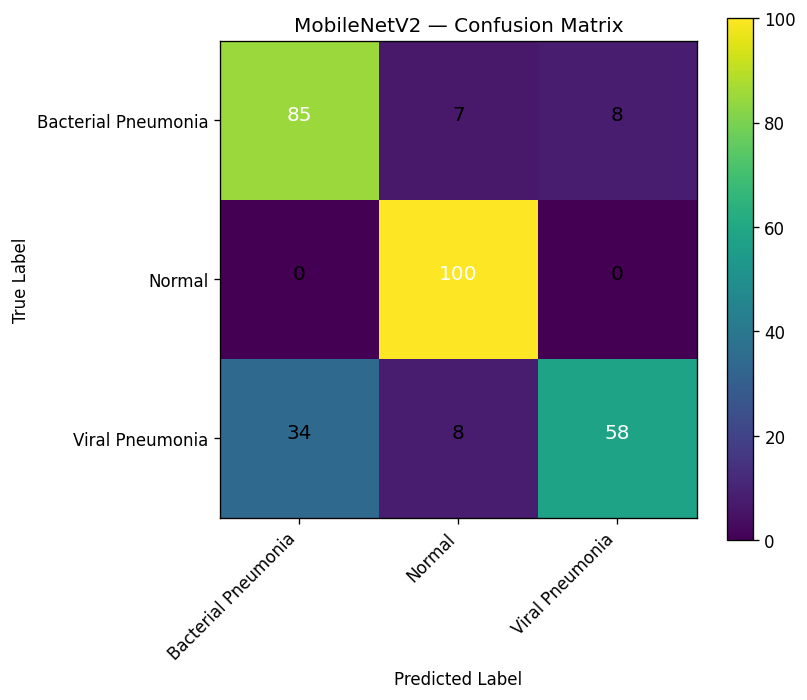


ROC CURVES — ONE-VS-REST


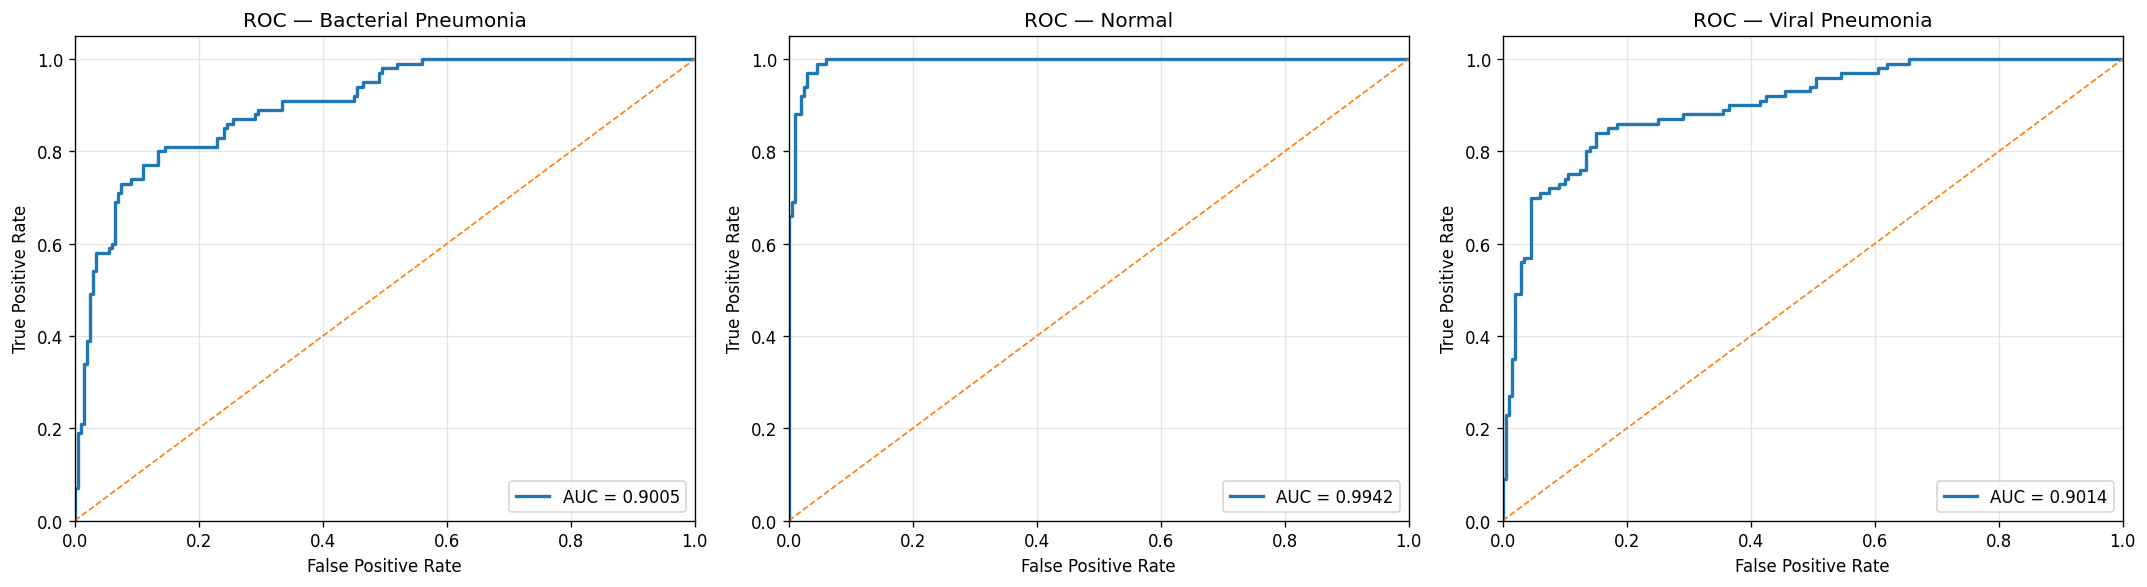


PRECISION-RECALL CURVES


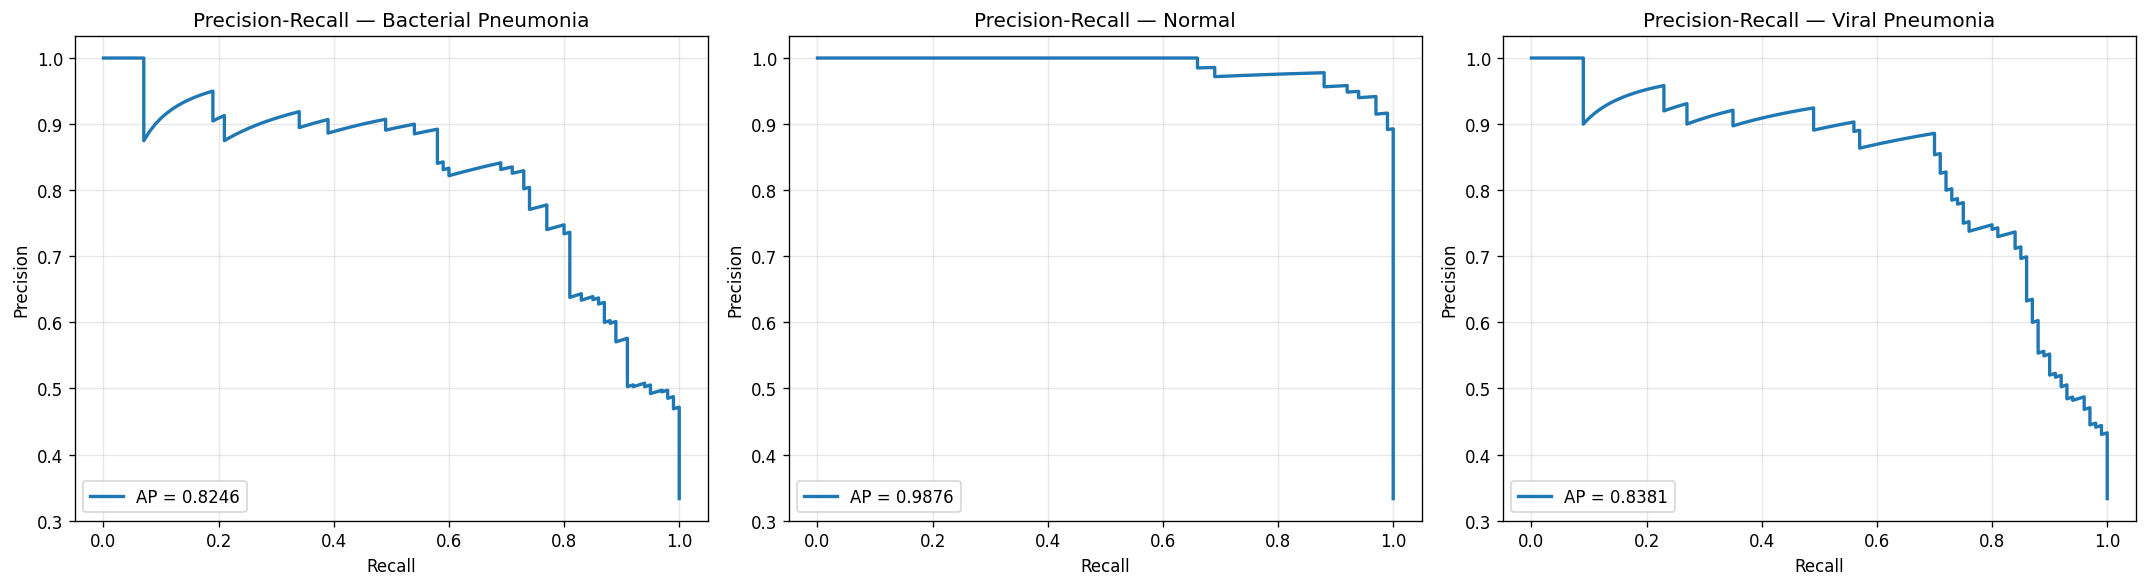


DATASET STATISTICS
Total Samples Evaluated: 300
Bacterial Pneumonia: 100 images
Normal: 100 images
Viral Pneumonia: 100 images

PREDICTION STATISTICS
Correct Predictions   : 243
Incorrect Predictions : 57
Accuracy              : 81.00%

PREDICTION CONFIDENCE
Mean Confidence   : 0.6673
Minimum Confidence: 0.3524
Maximum Confidence: 0.9897


FINAL MOBILENETV2 EVALUATION SUMMARY
Test Accuracy       : nan%
Test Precision      : nan
Test Recall         : nan
Macro Precision     : 0.8209
Macro Recall        : 0.8100
Macro F1-Score      : 0.8018
Macro Specificity   : 0.9050
Macro AUC-ROC       : 0.9320
Weighted F1-Score   : 0.8018
Total Test Samples  : 300

MobileNetV2 evaluation completed successfully.


In [2]:
# ============================================================
# PNEUMOSCAN AI
# MobileNetV2 — Detailed 3-Class Evaluation
# ============================================================
#
# Model:
#   MobileNetV2 + Custom Dense Classification Head
#
# Classes:
#   Bacterial Pneumonia
#   Viral Pneumonia
#   Normal
#
# Input Size:
#   224 x 224 x 3
#
# Preprocessing:
#   MobileNetV2 preprocess_input
#
# Evaluation:
#   100 images per class
#
# Metrics:
#   Accuracy
#   Precision
#   Recall / Sensitivity
#   Specificity
#   F1-Score
#   AUC-ROC
#   Macro Average
#   Weighted Average
#   Confusion Matrix
#   ROC Curves
#   Precision-Recall Curves
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import random
import shutil
import glob
import numpy as np
import matplotlib.pyplot as plt

from itertools import product
from IPython.display import display, clear_output
import ipywidgets as widgets

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    precision_recall_fscore_support,
    accuracy_score
)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# 3. GOOGLE DRIVE PATHS
# ============================================================

BASE_DIR = "/content/drive/MyDrive/pneumonia_detection_system"

# IMPORTANT:
# This is the MobileNetV2 model saved by your training code.
MODEL_PATH = os.path.join(
    BASE_DIR,
    "model",
    "latest_mobilenetv2_pneumonia_balanced.keras"
)

# Existing evaluation dataset
SOURCE_TEST_DIR = "/content/drive/MyDrive/Pneumonia_90_10_Splitted/test"

# Sampled evaluation dataset
SAMPLED_TEST_DIR = os.path.join(
    BASE_DIR,
    "evaluation",
    "mobilenetv2_sample_test_300"
)


# ============================================================
# 4. EVALUATION SETTINGS
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SAMPLES_PER_CLASS = 100

CLASS_NAMES = [
    "Bacterial Pneumonia",
    "Viral Pneumonia",
    "Normal"
]


# ============================================================
# 5. DISPLAY INFORMATION
# ============================================================

print("=" * 70)
print("PNEUMOSCAN AI — MobileNetV2 Evaluation")
print("=" * 70)

print("\nModel Path:")
print(MODEL_PATH)

print("\nTest Dataset:")
print(SOURCE_TEST_DIR)

print("\nEvaluation Image Size:", IMG_SIZE)
print("Batch Size:", BATCH_SIZE)
print("Samples Per Class:", SAMPLES_PER_CLASS)

print("\nClasses:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {i}: {cls}")


# ============================================================
# 6. CHECK MODEL AND DATASET
# ============================================================

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"\nMobileNetV2 model not found:\n{MODEL_PATH}\n"
        "\nMake sure the model exists in Google Drive."
    )

if not os.path.isdir(SOURCE_TEST_DIR):
    raise FileNotFoundError(
        f"\nTest dataset not found:\n{SOURCE_TEST_DIR}\n"
        "\nCheck the dataset path."
    )

print("\nModel and dataset paths verified successfully.")


# ============================================================
# 7. CUSTOM FOCAL LOSS
# ============================================================
#
# This is the SAME focal loss used during MobileNetV2 training.
# gamma = 2.0
# alpha = 1.0
# ============================================================

def focal_loss(gamma=2.0, alpha=1.0):

    def focal_crossentropy(y_true, y_pred):

        y_true = tf.cast(y_true, tf.float32)

        ce = tf.keras.losses.categorical_crossentropy(
            y_true,
            y_pred
        )

        pt = tf.reduce_sum(
            y_true * y_pred,
            axis=-1
        )

        fl = (
            alpha
            * tf.pow(1.0 - pt, gamma)
            * ce
        )

        return fl

    return focal_crossentropy


# ============================================================
# 8. CREATE SAMPLED TEST DATASET
# ============================================================

def create_sampled_test_folder(
    src_test_dir,
    dst_sample_dir,
    class_names,
    samples_per_class=100,
    seed=42
):

    random.seed(seed)

    # Remove previous sample
    if os.path.exists(dst_sample_dir):
        shutil.rmtree(dst_sample_dir)

    os.makedirs(dst_sample_dir, exist_ok=True)

    messages = []
    total_sampled = 0

    for cls in class_names:

        src_cls_dir = os.path.join(
            src_test_dir,
            cls
        )

        dst_cls_dir = os.path.join(
            dst_sample_dir,
            cls
        )

        os.makedirs(
            dst_cls_dir,
            exist_ok=True
        )

        if not os.path.isdir(src_cls_dir):

            messages.append(
                f"Missing class folder: {src_cls_dir}"
            )

            continue

        # Supported image formats
        patterns = [
            "*.jpg",
            "*.jpeg",
            "*.png",
            "*.bmp",
            "*.tif",
            "*.tiff"
        ]

        files = []

        for pattern in patterns:

            files.extend(
                glob.glob(
                    os.path.join(
                        src_cls_dir,
                        pattern
                    )
                )
            )

        n_available = len(files)

        if n_available == 0:

            messages.append(
                f"{cls}: No images found."
            )

            continue

        # Sample exactly 100 where possible
        if n_available <= samples_per_class:

            chosen = files

            messages.append(
                f"{cls}: {n_available} available — using all."
            )

        else:

            chosen = random.sample(
                files,
                samples_per_class
            )

            messages.append(
                f"{cls}: sampled {samples_per_class} "
                f"of {n_available} images."
            )

        # Copy selected images
        for fpath in chosen:

            destination = os.path.join(
                dst_cls_dir,
                os.path.basename(fpath)
            )

            shutil.copy2(
                fpath,
                destination
            )

        total_sampled += len(chosen)

    messages.append(
        f"Total sampled images: {total_sampled}"
    )

    return messages


print("\n" + "=" * 70)
print("CREATING EVALUATION TEST SET")
print("=" * 70)

messages = create_sampled_test_folder(
    SOURCE_TEST_DIR,
    SAMPLED_TEST_DIR,
    CLASS_NAMES,
    SAMPLES_PER_CLASS,
    SEED
)

for message in messages:
    print(message)


# ============================================================
# 9. LOAD MOBILE NET V2 MODEL
# ============================================================

print("\n" + "=" * 70)
print("LOADING MOBILENETV2 MODEL")
print("=" * 70)

_model = load_model(
    MODEL_PATH,
    custom_objects={
        "focal_crossentropy": focal_loss()
    }
)

print("\nMobileNetV2 model loaded successfully.")


# ============================================================
# 10. MODEL INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("MODEL INFORMATION")
print("=" * 70)

_model.summary()

total_params = _model.count_params()

print("\nTotal Parameters:")
print(f"{total_params:,}")


# ============================================================
# 11. LOAD TEST DATA
# ============================================================
#
# IMPORTANT:
# MobileNetV2 was trained using:
#
# preprocess_input
#
# NOT:
# rescale=1./255
# ============================================================

print("\n" + "=" * 70)
print("LOADING TEST DATASET")
print("=" * 70)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

_test_gen = test_datagen.flow_from_directory(
    SAMPLED_TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

_class_indices = _test_gen.class_indices

print("\nClass Indices:")
print(_class_indices)

print("\nTotal Evaluation Images:")
print(len(_test_gen.filenames))


# ============================================================
# 12. VERIFY CLASS ORDER
# ============================================================

idx_to_name = {
    value: key
    for key, value in _class_indices.items()
}

ordered_names = [
    idx_to_name[i]
    for i in range(len(idx_to_name))
]

print("\nActual Generator Class Order:")

for i, name in enumerate(ordered_names):
    print(f"{i}: {name}")


# ============================================================
# 13. MODEL EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("OVERALL MODEL EVALUATION")
print("=" * 70)

evaluation_results = _model.evaluate(
    _test_gen,
    verbose=1
)

print("\nRaw Evaluation Results:")

for name, value in zip(
    _model.metrics_names,
    evaluation_results
):
    print(f"{name}: {value:.6f}")


# Extract metrics safely
metric_dict = dict(
    zip(
        _model.metrics_names,
        evaluation_results
    )
)

test_loss = metric_dict.get("loss", np.nan)
test_accuracy = metric_dict.get("accuracy", np.nan)
test_precision = metric_dict.get("precision", np.nan)
test_recall = metric_dict.get("recall", np.nan)


print("\n" + "-" * 50)
print("FINAL TEST METRICS")
print("-" * 50)

print(f"Test Loss     : {test_loss:.5f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Precision     : {test_precision:.4f}")
print(f"Recall        : {test_recall:.4f}")


# ============================================================
# 14. GENERATE PREDICTIONS
# ============================================================

print("\n" + "=" * 70)
print("GENERATING PREDICTIONS")
print("=" * 70)

# Ground truth
y_true = _test_gen.classes

# Probability predictions
y_prob = _model.predict(
    _test_gen,
    verbose=1
)

# Predicted class
y_pred = np.argmax(
    y_prob,
    axis=1
)

print("\nPrediction generation completed.")


# ============================================================
# 15. BASIC ACCURACY VERIFICATION
# ============================================================

correct_predictions = np.sum(
    y_true == y_pred
)

total_predictions = len(y_true)

manual_accuracy = (
    correct_predictions /
    total_predictions
)

print("\n" + "=" * 70)
print("PREDICTION SUMMARY")
print("=" * 70)

print(
    f"Correct Predictions : "
    f"{correct_predictions}/{total_predictions}"
)

print(
    f"Incorrect Predictions : "
    f"{total_predictions - correct_predictions}/"
    f"{total_predictions}"
)

print(
    f"Calculated Accuracy : "
    f"{manual_accuracy * 100:.2f}%"
)

print(
    f"Evaluate() Accuracy : "
    f"{test_accuracy * 100:.2f}%"
)


# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(ordered_names)))
)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)

print("\nConfusion Matrix Breakdown:")

for i, true_class in enumerate(ordered_names):

    for j, predicted_class in enumerate(ordered_names):

        print(
            f"{true_class} → "
            f"{predicted_class}: "
            f"{cm[i, j]}"
        )


# ============================================================
# 17. PER-CLASS PRECISION / RECALL / F1
# ============================================================

precision_per_class, recall_per_class, f1_per_class, support_per_class = \
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(ordered_names))),
        zero_division=0
    )


print("\n" + "=" * 70)
print("PER-CLASS METRICS")
print("=" * 70)

for i, class_name in enumerate(ordered_names):

    print(f"\n{class_name}")

    print(
        f"  Precision : "
        f"{precision_per_class[i]:.4f}"
    )

    print(
        f"  Recall    : "
        f"{recall_per_class[i]:.4f}"
    )

    print(
        f"  F1-Score  : "
        f"{f1_per_class[i]:.4f}"
    )

    print(
        f"  Support   : "
        f"{support_per_class[i]}"
    )


# ============================================================
# 18. SPECIFICITY FOR EACH CLASS
# ============================================================

print("\n" + "=" * 70)
print("PER-CLASS SPECIFICITY")
print("=" * 70)

specificity_per_class = []

for i, class_name in enumerate(ordered_names):

    true_positive = cm[i, i]

    false_positive = (
        np.sum(cm[:, i]) -
        true_positive
    )

    false_negative = (
        np.sum(cm[i, :]) -
        true_positive
    )

    true_negative = (
        np.sum(cm) -
        true_positive -
        false_positive -
        false_negative
    )

    if (true_negative + false_positive) > 0:

        specificity = (
            true_negative /
            (true_negative + false_positive)
        )

    else:

        specificity = 0.0

    specificity_per_class.append(
        specificity
    )

    print(
        f"{class_name}: "
        f"{specificity:.4f}"
    )


# ============================================================
# 19. AUC-ROC FOR EACH CLASS
# ============================================================

print("\n" + "=" * 70)
print("AUC-ROC — ONE-VS-REST")
print("=" * 70)

auc_scores = []

for class_idx, class_name in enumerate(ordered_names):

    y_true_binary = (
        y_true == class_idx
    ).astype(int)

    class_scores = y_prob[:, class_idx]

    try:

        auc_class = roc_auc_score(
            y_true_binary,
            class_scores
        )

    except ValueError:

        auc_class = float("nan")

    auc_scores.append(
        auc_class
    )

    print(
        f"{class_name}: "
        f"{auc_class:.4f}"
    )


# ============================================================
# 20. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=ordered_names,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 21. MACRO AVERAGES
# ============================================================

precision_macro = np.mean(
    precision_per_class
)

recall_macro = np.mean(
    recall_per_class
)

f1_macro = np.mean(
    f1_per_class
)

auc_macro = np.nanmean(
    auc_scores
)

specificity_macro = np.mean(
    specificity_per_class
)


print("\n" + "=" * 70)
print("MACRO AVERAGES")
print("=" * 70)

print(
    f"Precision (Macro)   : "
    f"{precision_macro:.4f}"
)

print(
    f"Recall (Macro)      : "
    f"{recall_macro:.4f}"
)

print(
    f"F1-Score (Macro)    : "
    f"{f1_macro:.4f}"
)

print(
    f"Specificity (Macro) : "
    f"{specificity_macro:.4f}"
)

print(
    f"AUC-ROC (Macro)     : "
    f"{auc_macro:.4f}"
)


# ============================================================
# 22. WEIGHTED AVERAGES
# ============================================================

weighted_precision = np.average(
    precision_per_class,
    weights=support_per_class
)

weighted_recall = np.average(
    recall_per_class,
    weights=support_per_class
)

weighted_f1 = np.average(
    f1_per_class,
    weights=support_per_class
)

weighted_specificity = np.average(
    specificity_per_class,
    weights=support_per_class
)

weighted_auc = np.average(
    np.nan_to_num(auc_scores),
    weights=support_per_class
)


print("\n" + "=" * 70)
print("WEIGHTED AVERAGES")
print("=" * 70)

print(
    f"Precision (Weighted)   : "
    f"{weighted_precision:.4f}"
)

print(
    f"Recall (Weighted)      : "
    f"{weighted_recall:.4f}"
)

print(
    f"F1-Score (Weighted)    : "
    f"{weighted_f1:.4f}"
)

print(
    f"Specificity (Weighted) : "
    f"{weighted_specificity:.4f}"
)

print(
    f"AUC-ROC (Weighted)     : "
    f"{weighted_auc:.4f}"
)


# ============================================================
# 23. CONFUSION MATRIX VISUALIZATION
# ============================================================

print("\n" + "=" * 70)
print("CONFUSION MATRIX VISUALIZATION")
print("=" * 70)

fig = plt.figure(
    figsize=(7, 6),
    dpi=120
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "MobileNetV2 — Confusion Matrix"
)

plt.colorbar()

tick_marks = np.arange(
    len(ordered_names)
)

plt.xticks(
    tick_marks,
    ordered_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_marks,
    ordered_names
)

threshold = cm.max() / 2.0

for i, j in product(
    range(cm.shape[0]),
    range(cm.shape[1])
):

    plt.text(
        j,
        i,
        format(cm[i, j], "d"),
        horizontalalignment="center",
        color="white"
        if cm[i, j] > threshold
        else "black",
        fontsize=12
    )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")

plt.tight_layout()
plt.show()


# ============================================================
# 24. ROC CURVES
# ============================================================

print("\n" + "=" * 70)
print("ROC CURVES — ONE-VS-REST")
print("=" * 70)

fig, axes = plt.subplots(
    1,
    len(ordered_names),
    figsize=(18, 5),
    dpi=120
)

if len(ordered_names) == 1:
    axes = [axes]

for idx, class_name in enumerate(ordered_names):

    y_true_binary = (
        y_true == idx
    ).astype(int)

    class_scores = y_prob[:, idx]

    try:

        fpr, tpr, _ = roc_curve(
            y_true_binary,
            class_scores
        )

        auc_score = auc_scores[idx]

        axes[idx].plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"AUC = {auc_score:.4f}"
        )

        axes[idx].plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            linewidth=1
        )

        axes[idx].set_xlim(
            [0.0, 1.0]
        )

        axes[idx].set_ylim(
            [0.0, 1.05]
        )

        axes[idx].set_xlabel(
            "False Positive Rate"
        )

        axes[idx].set_ylabel(
            "True Positive Rate"
        )

        axes[idx].set_title(
            f"ROC — {class_name}"
        )

        axes[idx].legend(
            loc="lower right"
        )

        axes[idx].grid(
            True,
            alpha=0.3
        )

    except Exception as e:

        axes[idx].text(
            0.5,
            0.5,
            f"ROC unavailable\n{e}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


# ============================================================
# 25. PRECISION-RECALL CURVES
# ============================================================

print("\n" + "=" * 70)
print("PRECISION-RECALL CURVES")
print("=" * 70)

fig, axes = plt.subplots(
    1,
    len(ordered_names),
    figsize=(18, 5),
    dpi=120
)

if len(ordered_names) == 1:
    axes = [axes]

for idx, class_name in enumerate(ordered_names):

    y_true_binary = (
        y_true == idx
    ).astype(int)

    class_scores = y_prob[:, idx]

    try:

        precision_curve, recall_curve, _ = \
            precision_recall_curve(
                y_true_binary,
                class_scores
            )

        ap_score = average_precision_score(
            y_true_binary,
            class_scores
        )

        axes[idx].plot(
            recall_curve,
            precision_curve,
            linewidth=2,
            label=f"AP = {ap_score:.4f}"
        )

        axes[idx].set_xlabel(
            "Recall"
        )

        axes[idx].set_ylabel(
            "Precision"
        )

        axes[idx].set_title(
            f"Precision-Recall — {class_name}"
        )

        axes[idx].legend(
            loc="lower left"
        )

        axes[idx].grid(
            True,
            alpha=0.3
        )

    except Exception as e:

        axes[idx].text(
            0.5,
            0.5,
            f"PR unavailable\n{e}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


# ============================================================
# 26. CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("DATASET STATISTICS")
print("=" * 70)

print(
    f"Total Samples Evaluated: "
    f"{total_predictions}"
)

for i, class_name in enumerate(ordered_names):

    count = np.sum(
        y_true == i
    )

    print(
        f"{class_name}: "
        f"{count} images"
    )


# ============================================================
# 27. CORRECT / INCORRECT PREDICTION STATISTICS
# ============================================================

incorrect_predictions = (
    total_predictions -
    correct_predictions
)

print("\n" + "=" * 70)
print("PREDICTION STATISTICS")
print("=" * 70)

print(
    f"Correct Predictions   : "
    f"{correct_predictions}"
)

print(
    f"Incorrect Predictions : "
    f"{incorrect_predictions}"
)

print(
    f"Accuracy              : "
    f"{manual_accuracy * 100:.2f}%"
)


# ============================================================
# 28. CONFIDENCE STATISTICS
# ============================================================

prediction_confidence = np.max(
    y_prob,
    axis=1
)

print("\n" + "=" * 70)
print("PREDICTION CONFIDENCE")
print("=" * 70)

print(
    f"Mean Confidence   : "
    f"{np.mean(prediction_confidence):.4f}"
)

print(
    f"Minimum Confidence: "
    f"{np.min(prediction_confidence):.4f}"
)

print(
    f"Maximum Confidence: "
    f"{np.max(prediction_confidence):.4f}"
)


# ============================================================
# 29. FINAL EVALUATION SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("FINAL MOBILENETV2 EVALUATION SUMMARY")
print("=" * 70)

print(
    f"Test Accuracy       : "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Test Precision      : "
    f"{test_precision:.4f}"
)

print(
    f"Test Recall         : "
    f"{test_recall:.4f}"
)

print(
    f"Macro Precision     : "
    f"{precision_macro:.4f}"
)

print(
    f"Macro Recall        : "
    f"{recall_macro:.4f}"
)

print(
    f"Macro F1-Score      : "
    f"{f1_macro:.4f}"
)

print(
    f"Macro Specificity   : "
    f"{specificity_macro:.4f}"
)

print(
    f"Macro AUC-ROC       : "
    f"{auc_macro:.4f}"
)

print(
    f"Weighted F1-Score   : "
    f"{weighted_f1:.4f}"
)

print(
    f"Total Test Samples  : "
    f"{total_predictions}"
)

print("=" * 70)

print("\nMobileNetV2 evaluation completed successfully.")

In [ ]:
# Single Colab cell — Final Improved Test Pipeline (upload -> validate -> predict -> Grad-CAM -> CLIP advisory -> PDF)

# 0) Install required libs
!pip install -q transformers fpdf ftfy

# ---------------------------
import os, time
from google.colab import drive, files
import numpy as np
import cv2
from PIL import Image
from fpdf import FPDF

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import load_model, Model

from transformers import CLIPProcessor, CLIPModel

# ---------------------------
# === CONFIG ===
BASE_DIR = "/content/drive/MyDrive/pneumonia_detection_system"
MODEL_PATH = os.path.join(BASE_DIR, "model", "mobilenetv2_pneumonia_new_model.keras")
HEATMAP_DIR = os.path.join(BASE_DIR, "heatmap")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
CLIP_DIR = os.path.join(BASE_DIR, "clip")
IMG_SIZE = (224, 224)
CLASS_NAMES = ["Bacterial Pneumonia", "Normal", "Viral Pneumonia"]

os.makedirs(HEATMAP_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(CLIP_DIR, exist_ok=True)

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

# ---------------------------
# 1) Mount Drive
#drive.mount('/content/drive', force_remount=False)

# ---------------------------
# 2) Upload image
print("Upload one X-ray image now (use the file browser dialog).")
uploaded = files.upload()
if len(uploaded) == 0:
    raise SystemExit("No file uploaded — stop.")
image_filename = list(uploaded.keys())[0]
uploaded_path = os.path.join("/content", image_filename)
print("Uploaded:", image_filename)

# ---------------------------
# 3) Improved Image Validation
def heuristic_validate(image_path, min_mean=20, max_mean=230, min_var=100, edge_threshold=0.0008):
    try:
        img_bgr = cv2.imread(image_path)
        if img_bgr is None:
            return False, "File could not be read as image."
        if img_bgr.ndim == 2:
            img_bgr = cv2.cvtColor(img_bgr, cv2.COLOR_GRAY2BGR)
        h, w = img_bgr.shape[:2]
        if h < 100 or w < 100:
            return False, f"Image too small ({w}x{h})."
        resized = cv2.resize(img_bgr, IMG_SIZE)
        mean_pix = float(np.mean(resized))
        if mean_pix < min_mean or mean_pix > max_mean:
            return False, f"Brightness out of range (mean={mean_pix:.1f})."
        gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
        var = float(np.var(gray))
        if var < min_var:
            return False, f"Low variance: {var:.1f}"
        edges = cv2.Canny(gray, 50, 150)
        edge_density = edges.sum() / (IMG_SIZE[0]*IMG_SIZE[1]*255.0)
        if edge_density < edge_threshold:
            return False, "Low edge density (not X-ray-like)."
        return True, "Heuristic checks passed."
    except Exception as e:
        return False, f"Heuristic validation error: {e}"

def color_saturation_check(image_path, sat_thresh=40):
    try:
        img = cv2.imread(image_path)
        if img is None:
            return False, "Cannot read image."
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        sat_mean = float(np.mean(hsv[:,:,1]))
        if sat_mean > sat_thresh:
            return False, f"Too colorful (sat={sat_mean:.1f})."
        return True, f"Saturation OK (sat={sat_mean:.1f})."
    except Exception as e:
        return False, f"Saturation check error: {e}"

def clip_modality_check(pil_img, clip_model_name=CLIP_MODEL_NAME, threshold=0.25):
    processor = CLIPProcessor.from_pretrained(clip_model_name)
    model = CLIPModel.from_pretrained(clip_model_name)
    prompts = ["This is a chest X-ray image.", "This is a normal photograph."]
    inputs = processor(text=prompts, images=pil_img, return_tensors="pt", padding=True)
    outputs = model(**inputs)
    logits = outputs.logits_per_image.softmax(dim=1).detach().cpu().numpy()[0]
    score_xray = float(logits[0]); score_photo = float(logits[1])
    diff = score_xray - score_photo
    return True, (diff > threshold), diff

# ---------------------------
# === EXTRA VALIDATION FUNCTIONS ===
def blur_check(image_path, threshold=100.0):
    try:
        img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        lap = cv2.Laplacian(img_gray, cv2.CV_64F)
        var_lap = lap.var()
        if var_lap < threshold:
            return False, f"Image too blurry (Laplacian variance={var_lap:.1f})"
        return True, f"Blur OK (variance={var_lap:.1f})"
    except Exception as e:
        return False, f"Blur check error: {e}"

def noise_check(image_path, noise_thresh=0.05):
    try:
        img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)/255.0
        noise_level = np.mean(np.abs(img_gray - cv2.GaussianBlur(img_gray,(3,3),0)))
        if noise_level > noise_thresh:
            return False, f"High noise detected ({noise_level:.3f})"
        return True, f"Noise OK ({noise_level:.3f})"
    except Exception as e:
        return False, f"Noise check error: {e}"

def aspect_ratio_check(image_path, min_ratio=0.8, max_ratio=1.5):
    try:
        img = cv2.imread(image_path)
        h, w = img.shape[:2]
        ratio = w/h
        if ratio < min_ratio or ratio > max_ratio:
            return False, f"Aspect ratio abnormal (w/h={ratio:.2f})"
        return True, f"Aspect ratio OK (w/h={ratio:.2f})"
    except Exception as e:
        return False, f"Aspect ratio check error: {e}"

def histogram_check(image_path, min_mean=30, max_mean=220):
    try:
        img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mean_pix = float(np.mean(img_gray))
        if mean_pix < min_mean or mean_pix > max_mean:
            return False, f"Histogram out of range (mean={mean_pix:.1f})"
        return True, f"Histogram OK (mean={mean_pix:.1f})"
    except Exception as e:
        return False, f"Histogram check error: {e}"

# ---------------------------
# Run all checks
heur_ok, heur_msg = heuristic_validate(uploaded_path)
sat_ok, sat_msg = color_saturation_check(uploaded_path)
blur_ok, blur_msg = blur_check(uploaded_path)
noise_ok, noise_msg = noise_check(uploaded_path)
ar_ok, ar_msg = aspect_ratio_check(uploaded_path)
hist_ok, hist_msg = histogram_check(uploaded_path)

validation_notes = [heur_msg, sat_msg, blur_msg, noise_msg, ar_msg, hist_msg]

pil_for_clip = None
try: pil_for_clip = Image.open(uploaded_path).convert("RGB")
except: pass

clip_checked, clip_is_xray, clip_diff = False, False, 0.0
if pil_for_clip:
    try:
        clip_checked, clip_is_xray, clip_diff = clip_modality_check(pil_for_clip)
        validation_notes.append(f"CLIP check: is_xray={clip_is_xray}, diff={clip_diff:.3f}")
    except: pass

# Decision
validation_ok = all([heur_ok, sat_ok, blur_ok, noise_ok, ar_ok, hist_ok])
if clip_checked and not clip_is_xray:
    validation_ok = False
    validation_notes.append("Rejected: CLIP says NOT an X-ray.")

if not validation_ok:
    print("Validation failed:", validation_notes)
    raise SystemExit("Stopping pipeline: invalid image.")
else:
    print("Validation passed:", validation_notes)


Upload one X-ray image now (use the file browser dialog).


Saving 190.jpeg to 190.jpeg
Uploaded: 190.jpeg


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Validation passed: ['Heuristic checks passed.', 'Saturation OK (sat=0.0).', 'Blur OK (variance=142.0)', 'Noise OK (0.005)', 'Aspect ratio OK (w/h=1.00)', 'Histogram OK (mean=169.9)', 'CLIP check: is_xray=True, diff=1.000']
